***
# GROUP TERM PAPER 1 
# FIE463 - Spring, 2026
***

**Libraries**

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from matplotlib.ticker import PercentFormatter
from scipy.optimize import root_scalar, minimize_scalar

***
## PART 1 - Euler Equation Errors
***

### 1.1.

**Define Model Parameters**

In [61]:
@dataclass
class Parameters:
    
    beta:       float = 0.99**30        # Discount factor
    gamma:      float = 2.1             # Relative risk aversion
    tau:        float = 0.3             # Payroll tax rate
    phi:        float = 0.5             # Fraction of wealth bequathed by old capitalist
    alpha:      float = 0.36            # Capital share in production
    delta:      float = 1 - 0.94**30    # Capital depreciation 
    z:          float = 1.0             # Total factor productivity (TFP)
    Nw:         float = 0.8             # Fraction of workers
    Nk:         float = 0.2             # Fraction of capitalists

    # Taxation parameters for part 4 and 6
    tau_a:      float = 0.0             # Wealth tax rate. 0% to not influnce earlier parts. Value set to 5% in function call in part 4 
    tau_a_iid:  float = 0.05            # Uncertainty about tax rate next period. For part 6
    pi_a:       float = 0.0             # Probability of tax next period. Set value in part 6

par = Parameters()

**Define Standard Decimal Precision for Reporting**

In [62]:
# Decimal points
round_digits = 4

### 1.2.

**Calculate interest- and wage rate**

In [63]:
# Function based on workshop 07
def compute_prices(k, z, par):    
    """
    Return factor prices for a given capital-labor ratio, TFP, and parameters.

    Parameters
    ----------
    k : float
        Capital-labor ratio
    z : float
        Total factor productivity (TFP)
    par : Parameters
        Parameters for the given problem

    Returns
    -------
    r : float
        Return on capital after depreciation (interest rate)
    w : float
        Wage rate

    """

    # Interest rate
    r = par.alpha * z * k ** (par.alpha - 1) - par.delta    
    
    # Wage rate          
    w = (1 - par.alpha) * z * k**par.alpha                  

    return r, w

**Implement Euler Erros Equation**

In [64]:
def euler_err(K_next, K, par):
    """
    Compute the capitalist´ Euler equation error for a given capital stock today and tomorrow.
    Parameters
    ----------
    K_next : float
        Next-period aggregate capital stock.
    K : float
        Current aggregate capital stock.
    par : Parameters
        Model parameters.

    Returns
    -------
    float
        Euler equation error.

    """

    # Aggregate labour supply
    L = 0.5 * par.Nw

    # Capital-labour ratios
    k_t    = K / L
    k_next = K_next / L

    # Interest Rates (current and next period)
    r_t, _    = compute_prices(k_t,    par.z, par)        # _ since we don´t need the wage here
    r_next, _ = compute_prices(k_next, par.z, par)        # _ since we don´t need the wage here

    # Saving in asssets (last and current period)
    a_prev = 2.0 * K / par.Nk
    a_t    = 2.0 * K_next / par.Nk

    # Government Transfers from Wealth Tax (Part 4, 5 and 6)
    T_a_t    = 0.5 * par.Nk * par.tau_a * (1 + r_t)    * a_prev
    T_a_next = 0.5 * par.Nk * par.tau_a * (1 + r_next) * a_t

    # Bequest
    b_t = par.phi * (1 - par.tau_a) * (1 + r_t) * a_prev
    
    # Utility Young Capitalists (t) 
    c_young = b_t + T_a_t - a_t

    # Utility Old Capitalists (t+1)
    c_old_next = (1 - par.phi) * (1 - par.tau_a) * (1 + r_next) * a_t + T_a_next

    # Euler Equation Expressed
    lhs = c_young ** (-par.gamma)
    rhs = par.beta * (1 + r_next) * (1 - par.tau_a) * (1 - par.phi) * c_old_next**(-par.gamma)

    return lhs - rhs

### 1.3.

**Plot of Euler Equation for different levels of K**

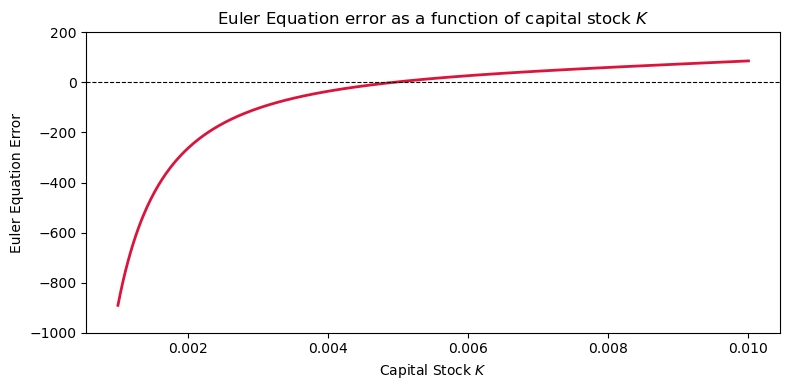

In [65]:
# Grid of Capital Levels
K_grid = np.linspace(0.001, 0.01, 500)

# Compute Euler equation errors for given Capital Levels
errors = np.array([euler_err(K, K, par) for K in K_grid])

# Plot Figure
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_grid, errors, color="crimson", lw=2)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xlabel("Capital Stock $K$")
ax.set_ylabel("Euler Equation Error")
ax.set_title(f"Euler Equation error as a function of capital stock $K$")
plt.ylim(-1000, 200)
plt.tight_layout()
plt.show()

***
## Part 2 - Steady state
***

### 2.1.

**Define Steady State Class**

In [66]:
@dataclass
class SteadyState:

    # Variables
    par:   Parameters = None         # Parameters used to compute equilibrium, given in term paper
    r:     float      = None         # Interest rate (return on capital)
    w:     float      = None         # Wage rate
    K:     float      = None         # Aggregate capital stock
    L:     float      = None         # Aggregate labor demand
    Y:     float      = None         # Aggregate output
    
    # Workers
    c_yw:  float      = None         # Consumption young worker
    c_ow:  float      = None         # Consumption old worker
    
    # Capitalists
    a:     float      = None         # Savings young capitalist
    b:     float      = None         # Bequest received young capitalist
    c_yk:  float      = None         # Consumption when young capitalist
    c_ok:  float      = None         # Consumption when old capitalist

### 2.2.

**Implement Compution of Steady State Function**

In [67]:
# tax_uncertain set to Bool: False to differ between part 2 and 6
def compute_steady_state(par, tax_uncertain=False):
    """
    Compute the steady-state equilibrium for the OLG model.

    Parameters
    ----------
    par : Parameters
        Parameters for the given problem
    tax_uncertain : bool, optional
        If True, solve the steady state using the uncertainty Euler equation.
        If False, use the deterministic Euler equation. Default is False.
    Returns
    -------
    eq : SteadyState
        Steady-state equilibrium of the OLG model
    """

    # Choose euler_err function type to differ part 2 and 6
    euler_err_type = euler_err_uncertain if tax_uncertain else euler_err 

    # Find K at Steady State
    res = root_scalar(lambda K: euler_err_type(K, K, par), bracket=(1e-4, 8e-3))

    # Check if Root Finder Convergences
    if not res.converged:
        print("Equilibrium root finder did not terminate successfully.")

    # Extract Steady State Capital Stock
    K_steady_state = res.root

    # Find Equilibrium Values at Steady State
    eq = SteadyState(par=par, K=K_steady_state)

    # Factor Prices at Equilibrium
    L          = 0.5 * par.Nw
    k          = K_steady_state / L
    eq.L       = L
    eq.r, eq.w = compute_prices(k, par.z, par)

    # Capitalists Variables at Equilibrium
    a       = 2.0 * K_steady_state / par.Nk
    T_a     = 0.5 * par.Nk * par.tau_a * (1 + eq.r) * a
    eq.a    = a
    eq.b    = par.phi * (1 - par.tau_a) * (1 + eq.r) * a
    eq.c_yk = eq.b + T_a - eq.a
    eq.c_ok = (1 - par.phi) * (1 - par.tau_a) * (1 + eq.r) * eq.a + T_a

    # Workers Variables at Equilibrium
    eq.c_yw = (1 - par.tau) * eq.w + T_a
    eq.c_ow = par.tau * eq.w + T_a

    # Output in Equilibrium
    eq.Y = par.z * K_steady_state**par.alpha * L**(1 - par.alpha)

    return eq

### 2.3.

**Compute and Report Steady State Equilibrium**

In [68]:
# Print Function based on workshop 06
def print_steady_state(eq):
    """
    Print equilibrium prices, allocations, and excess demand.

    Parameters
    ----------
    eq : SteadyState
        SteadyState of the OLG model
    """

    # Parameters at Equilibrium
    par = eq.par     

    # Goods Market Clearing Verification 
    C = 0.5*par.Nw*(eq.c_yw + eq.c_ow) + 0.5*par.Nk*(eq.c_yk + eq.c_ok)
    I = eq.K * par.delta

    # Print to Report 
    print("Steady State Equilibrium:")
    print("  Workers:")
    print(f"    c_yw = {eq.c_yw:.{round_digits}f}")
    print(f"    c_ow = {eq.c_ow:.{round_digits}f}")
    print("  Capitalists:")
    print(f"    a    = {eq.a:.{round_digits}f}")
    print(f"    b    = {eq.b:.{round_digits}f}")
    print(f"    c_yk = {eq.c_yk:.{round_digits}f}")
    print(f"    c_ok = {eq.c_ok:.{round_digits}f}")
    print("  Firms:")
    print(f"    K    = {eq.K:.{round_digits}f}")
    print(f"    L    = {eq.L:.{round_digits}f}")
    print(f"    Y    = {eq.Y:.{round_digits}f}")
    print("  Prices:")
    print(f"    r    = {eq.r:.{round_digits}f}")
    print(f"    w    = {eq.w:.{round_digits}f}")
    print("  Market Clearing:")
    print(f"    Goods market: {eq.Y - C - I:.2e}")

# Find Steady State at Eqilibrium
eq = compute_steady_state(par)

# Print Steady State to Report
print_steady_state(eq)

Steady State Equilibrium:
  Workers:
    c_yw = 0.0920
    c_ow = 0.0394
  Capitalists:
    a    = 0.0492
    b    = 0.1517
    c_yk = 0.1025
    c_ok = 0.1517
  Firms:
    K    = 0.0049
    L    = 0.4000
    Y    = 0.0821
  Prices:
    r    = 5.1629
    w    = 0.1314
  Market Clearing:
    Goods market: 6.07e-18


### 2.4.

**Compute the Implied Annualized net Interest Rate to check if results make sense**

In [69]:
r_annual = (1 + eq.r)**(1/30) - 1 
print(f"Implied annualized net interest rate: {r_annual:.{round_digits}f}")

Implied annualized net interest rate: 0.0625


**Understanding of Results**

*If the net annualized return is 6.25% and compounds over a 30-year period, the total return becomes 516%. This illustrates the power of the snowball effect of compounding.*

***
## Part 3 - Transition Dynamics
***

### 3.1.

**Create Simulation Class to store the simulated time series**

In [70]:
@dataclass
class Simulation:
    # Store Time Series Variables as NumPy Arrays
    
    K:    np.ndarray = None   # Aggregate capital stock
    r:    np.ndarray = None   # Interest rate (return on capital)
    w:    np.ndarray = None   # Wage rate
    Y:    np.ndarray = None   # Aggregate output
    b:    np.ndarray = None   # Bequest
    s:    np.ndarray = None   # Savings rate s
    c_yw: np.ndarray = None   # Consumption young worker
    c_ow: np.ndarray = None   # Consumption old worker
    c_yk: np.ndarray = None   # Consumption young capitalist
    c_ok: np.ndarray = None   # Consumption old capitalist

### 3.2.

**Implement Function to Compute the Transition Path for all Periods (t = 0, ... , T-1)**

In [71]:
# Arguments are Initial Capital Stock K0, number of periods T, and model Parameters. Function based on workshop 07
def simulate_olg(K0, T, par, uncertain=False):
    """
    Simulate transition dynamics of the OLG economy over T periods.

    Parameters
    ----------
    K0 : float
        Initial aggregate capital stock at period 0.
    T : int
        Number of periods to simulate.
    par : Parameters
        Model parameters.
    uncertain : bool, optional
        If True, use the uncertainty Euler equation. If False, use the
        deterministic Euler equation. Default is False.
    Returns
    -------
    sim : Simulation
        Simulation of the OLG model
    """

    sim      = Simulation()
    sim.K    = np.empty(T)
    sim.r    = np.empty(T)
    sim.w    = np.empty(T)
    sim.Y    = np.empty(T)
    sim.b    = np.empty(T)
    sim.s    = np.empty(T)
    sim.c_yw = np.empty(T)
    sim.c_ow = np.empty(T)
    sim.c_yk = np.empty(T)
    sim.c_ok = np.empty(T)

    # Initial Capital Stock
    sim.K[0] = K0

    # Use Eulers Error Equation
    euler_err_type = euler_err_uncertain if uncertain else euler_err # Differ from Part 6

    # Time Periods to Simulate
    for t in range(T - 1):
        
        # Aggregate labour supply
        L = 0.5 * par.Nw

        # Factor prices
        k = sim.K[t] / L
        sim.r[t], sim.w[t] = compute_prices(k, par.z, par)

        # Use root-finder on Euler equation to find K(t+1)
        res = root_scalar(
            lambda K_next: euler_err_type(K_next, sim.K[t], par),  
            bracket = (1e-4, 8e-3)
            )

        # Print message if root finder did not converge 
        if not res.converged:
            print(f"Root-finder did not converge at t={t}")

        # Store K(t+1) in simulation object
        sim.K[t + 1] = res.root

        # Saving in asssets (last and current period)
        a_prev = 2.0 * sim.K[t] / par.Nk
        a_t    = 2.0 * sim.K[t + 1] / par.Nk

        # Government transfer
        T_a = 0.5 * par.Nk * par.tau_a * (1 + sim.r[t]) * a_prev

        # Simulated Quantities
        sim.b[t]    = par.phi * (1 - par.tau_a) * (1 + sim.r[t]) * a_prev
        sim.s[t]    = a_t / (sim.b[t] + T_a)
        sim.c_yk[t] = sim.b[t] + T_a - a_t
        sim.c_ok[t] = (1 - par.phi) * (1 - par.tau_a) * (1 + sim.r[t]) * a_prev + T_a
        sim.c_yw[t] = (1 - par.tau) * sim.w[t] + T_a
        sim.c_ow[t] = par.tau * sim.w[t] + T_a
        sim.Y[t]    = par.z * sim.K[t]**par.alpha * L**(1 - par.alpha)

        # Goods Market Clearing Condition
        demand = 0.5*par.Nw*(sim.c_yw[t] + sim.c_ow[t]) + 0.5*par.Nk*(sim.c_yk[t] + sim.c_ok[t] + a_t)
        supply = sim.Y[t] + (1 - par.delta) * sim.K[t]
        assert abs(demand - supply) < 1e-8

    # Fill in last period (t = T-1)
    t = T - 1
    L = 0.5 * par.Nw
    k = sim.K[t] / L
    sim.r[t], sim.w[t] = compute_prices(k, par.z, par)
    a_prev       = 2.0 * sim.K[t] / par.Nk
    T_a          = 0.5 * par.Nk * par.tau_a * (1 + sim.r[t]) * a_prev
    sim.b[t]     = par.phi * (1 - par.tau_a) * (1 + sim.r[t]) * a_prev
    sim.s[t]     = sim.s[t - 1]
    sim.c_yk[t]  = sim.c_yk[t - 1]
    sim.c_ok[t]  = (1 - par.phi) * (1 - par.tau_a) * (1 + sim.r[t]) * a_prev + T_a
    sim.c_yw[t]  = (1 - par.tau) * sim.w[t] + T_a
    sim.c_ow[t]  = par.tau * sim.w[t] + T_a
    sim.Y[t]     = par.z * sim.K[t]**par.alpha * L**(1 - par.alpha)

    return sim

### 3.3.

**Calculate Precenent Deviation Function**

In [72]:
# Percent Deviation from steady state
def dev(series, ss):
    """
    Compute proportional deviation from a steady-state benchmark.

    Parameters
    ----------
    series : array-like
        Simulated time series values.
    ss : float
        Steady-state benchmark value.

    Returns
    -------
    array-like
        Relative deviation, computed as series / ss - 1.

    """

    return series / ss - 1

**Simulation of Economy Function**

In [73]:
def plot_simulation(eq, sim, eq_new=None):
    """
    Plot transition paths for key model variables in a 5-by-2 subplots.

    Parameters
    ----------
    eq : SteadyState
        Initial steady-state reference values.
    sim : Simulation
        Simulated transition path data.
    eq_new : SteadyState, optional
        New steady state used for comparison lines (e.g., after a policy
        change). If None, only the initial steady state is shown.
    """

    # Create Subplots
    fig, axes = plt.subplots(5, 2, figsize=(10, 12), sharex=True, constrained_layout=True)

    # Color of curve in plot
    series_color = "steelblue"

    # Steady state reference lines
    kwargs_ss  = dict(color="black", lw=1, ls="--", label="Steady State (τ = 0)")
    kwargs_new = dict(color="purple", lw=1, ls="--", label="Steady State (τ > 0)")

    # Order of panels
    panel_specs = [
        (axes[0, 0], "dev", sim.Y,    eq.Y,    eq_new.Y    if eq_new else None, "Output $Y_t$"),
        (axes[0, 1], "dev", sim.K,    eq.K,    eq_new.K    if eq_new else None, "Capital $K_t$"),
        (axes[1, 0], "dev", sim.w,    eq.w,    eq_new.w    if eq_new else None, "Wage $w_t$"),
        (axes[1, 1], "prct", sim.r,    eq.r,    eq_new.r    if eq_new else None, "Interest rate $r_t$"),
        (axes[2, 0], "dev", sim.b,    eq.b,    eq_new.b    if eq_new else None, "Bequest $b_t$"),
        (axes[2, 1], "prct", sim.s,    None,    None,                            "Savings rate $s_t$"),
        (axes[3, 0], "dev", sim.c_yw, eq.c_yw, eq_new.c_yw if eq_new else None, "Consumption young worker $c^w_y$"),
        (axes[3, 1], "dev", sim.c_ow, eq.c_ow, eq_new.c_ow if eq_new else None, "Consumption old worker $c^w_o$"),
        (axes[4, 0], "dev", sim.c_yk, eq.c_yk, eq_new.c_yk if eq_new else None, "Consumption young capitalist $c^k_y$"),
        (axes[4, 1], "dev", sim.c_ok, eq.c_ok, eq_new.c_ok if eq_new else None, "Consumption old capitalist $c^k_o$"),
    ]

    for ax, mode, series, ss_val, new_val, title in panel_specs:
        kwargs_series = dict(color=series_color, lw=1.5, marker="o", ms=3, label="Transistion Path")

        if mode == "dev":
            ax.plot(dev(series, ss_val), **kwargs_series)
            ax.axhline(0, **kwargs_ss)
            if new_val is not None:
                ax.axhline(dev(new_val, ss_val), **kwargs_new)
            ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=1))
        else:
            ax.plot(series, **kwargs_series)
            if ss_val is not None:
                ax.axhline(ss_val, **kwargs_ss)
            if new_val is not None:
                ax.axhline(new_val, **kwargs_new)
            ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=1))

        deviations = mode == "dev"
        if eq_new is not None:
            ylabel = "Deviation from initial SS" if deviations else None
        else:
            ylabel = "Deviation from SS" if deviations else None
        ax.set_ylabel(ylabel)

        ax.set_title(title)

    for ax in axes.flat:
        ax.set_xlim(0, 21)
        ax.set_xticks(np.arange(0, 22, 5))

    for ax in axes[4, :]:
        ax.set_xlabel("Period")

    axes[0, 0].legend(fontsize=8)
    plt.show()

### 3.4.

**Show Plot Simulation of Economy Function**

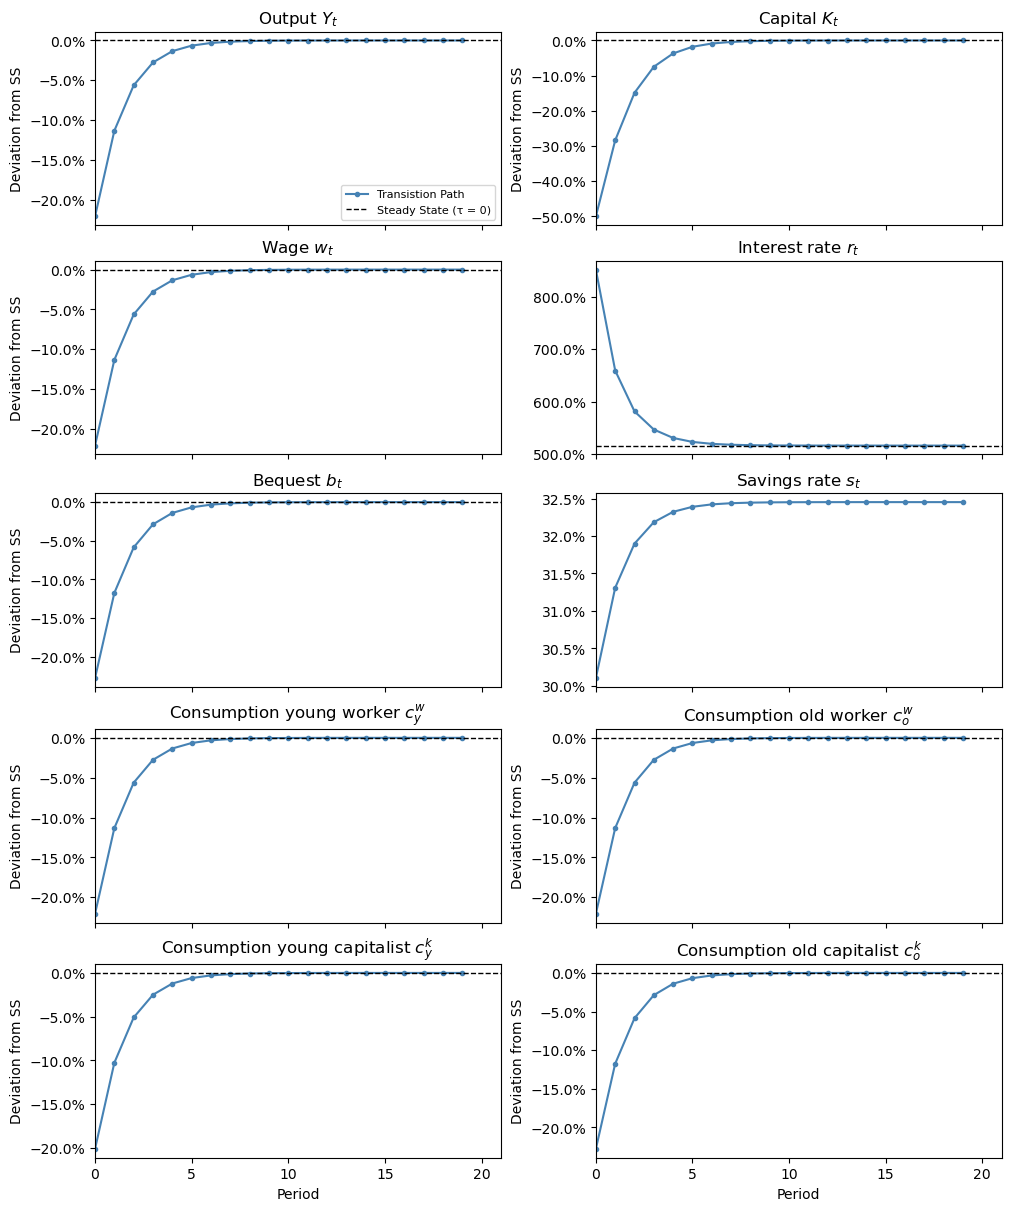

In [74]:
# Run and Plot Simulation
par = Parameters()
eq  = compute_steady_state(par)
sim = simulate_olg(K0=eq.K/2, T=20, par=par)
plot_simulation(eq, sim)

***
## Part 4 - Introduction of a Wealth Tax
***

### 4.1.

**Update Parameters to include Wealth Tax Rate**

In [75]:
# Wealth Tax parameter set at 5%
par_tax = Parameters(tau_a=0.05)

### 4.2.

*See comments in code for details where modifications has been made.*

### 4.3.

**Compute and Report the New Steady State with the Wealth Tax**

In [76]:
eq_tax = compute_steady_state(par_tax)
print("Wealth Tax included:")
print_steady_state(eq_tax)

# Savings rate s
s_original = eq.a / (eq.a + eq.c_yk) 
s_new      = eq_tax.a / (eq_tax.a + eq_tax.c_yk)
print(f"s (original steady state)            = {s_original:.{round_digits}f}")
print(f"s (new steady state with wealth tax) = {s_new:.{round_digits}f}")

Wealth Tax included:
Steady State Equilibrium:
  Workers:
    c_yw = 0.0910
    c_ow = 0.0399
  Capitalists:
    a    = 0.0457
    b    = 0.1402
    c_yk = 0.0959
    c_ok = 0.1416
  Firms:
    K    = 0.0046
    L    = 0.4000
    Y    = 0.0800
  Prices:
    r    = 5.4533
    w    = 0.1280
  Market Clearing:
    Goods market: -5.20e-18
s (original steady state)            = 0.3245
s (new steady state with wealth tax) = 0.3228


**Intuiton of our findings**

*The introduction of the wealth tax causes both the savings rate and the capital stock to fall in the new steady state with wealth tax at 5%*

*Savings rate at steady state is: 0.3245 (old) and 0.3228 (new), reduction of approximiation 0.5%*

*Capital stock at steady state is: 0.0049 (old) and 0.00456 (new), reduction of approximiation 7%*

*The wealth tax directly reduces the after-tax return on capitalists savings.*
*This makes saving less attractive, and young capitalists therefore choose to set aside a smaller share of their available wealth.*
*In addition, they receive lower bequest since the tax is imposed on the wealth transferred between generations. Both of these effects point in the same direction and cause the savings rate to decline.*

*Since the capital stock in this model is determined exclusively by the savings of capitalists, the lower savings rate translates directly into lower capital accumulation.*
*The result is a new steady state with a permanently lower capital stock than before.*

*Although the transfers from the tax partially compensate the capitalists, this is not sufficient to offset the negative effect on their incentives to save.*


### 4.4.

**Simulate Transition Path for T = 20 Periods: Economy starts in Steady State Without Wealth Tax**

In [77]:
# Simulate transition: Start from old Steady State and introduce wealth tax at t=0
sim_tax = simulate_olg(K0=eq.K, T=20, par=par_tax)

### 4.5.

**Plot Transition Paths for the same variables in Part 3**

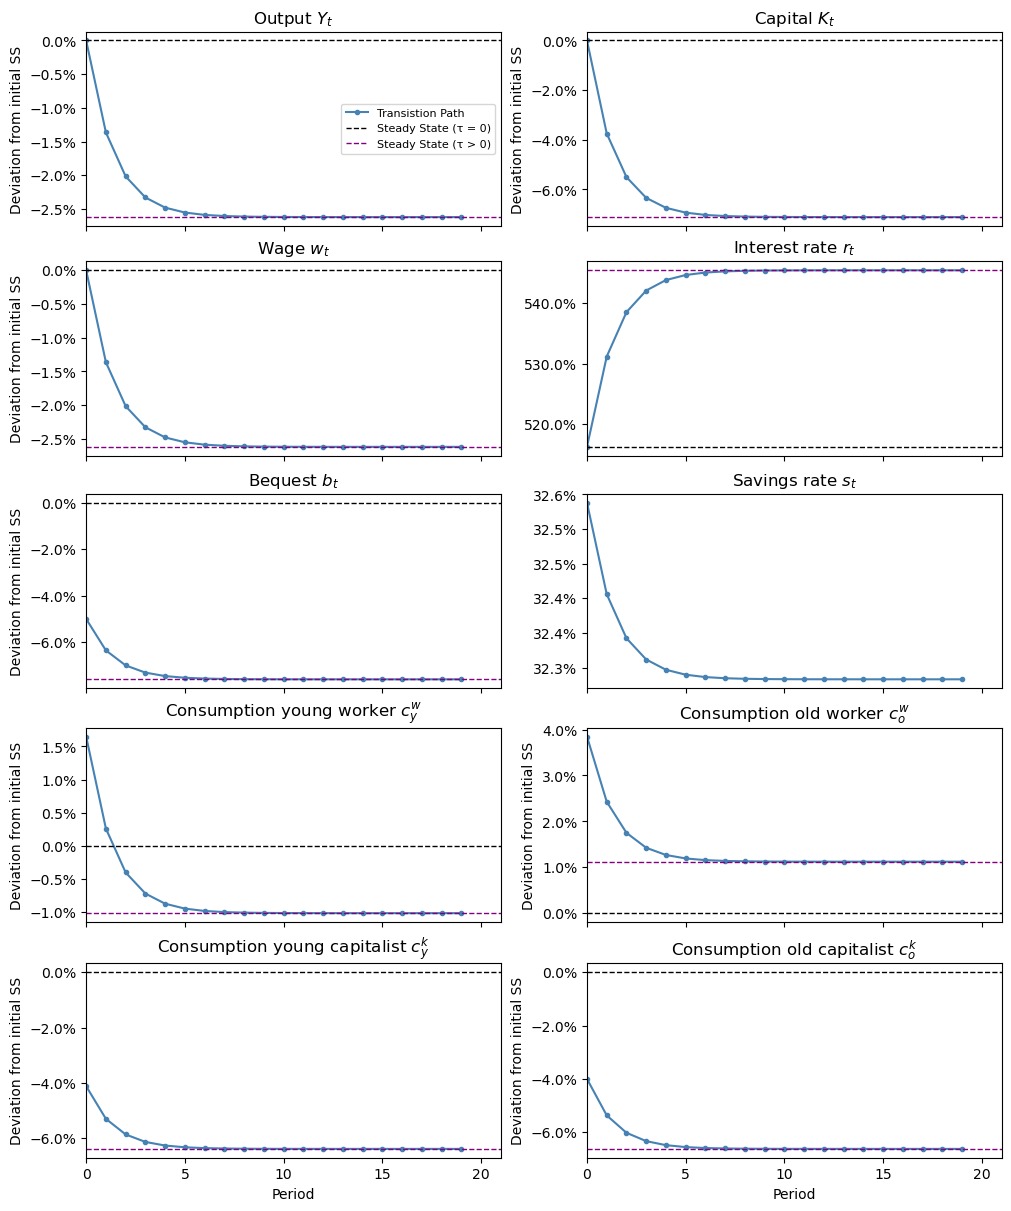

In [78]:
plot_simulation(eq, sim_tax, eq_new=eq_tax)

### 4.6.

**Discussion of who is better or worse off along the Transition and in the New Steady State**

*The introduction of the wealth tax creates clear distributional effects, both during the transition and in the new steady state.* 

*Workers are the winners.*

*The tax finances a lump-sum transfer T_a_t distributed to all households. Since workers make up about 80% of the population, they benefit most from the redistribution. During the transition, old workers immediately see higher consumption in period t=0 because they receive transfers without bearing the tax cost. In the graph, old worker consumption c_ow initially rises by about 4% deviations relative to the initial steady state before gradually declining and stabilizing around 1% above it. Young workers also gain, although wages fall somewhat over time as the capital stock declines. In the new steady state, workers remain permanently better off.* 

*Capitalists are the losers.* 

*The tax directly reduces their wealth, lowering bequest b_t from the first period. The bequest variable drops by about 5% deviations initially and converges to roughly −7.5% in the new steady state. Lower bequest reduces savings by young capitalists, further decreasing the capital stock. As capital declines, output Y falls and converges to about −2.6%. Consequently, both young and old capitalists consume significantly less than before the tax was introduced.*

***
## Part 5 - Social Welfare and the Optimal Wealth Tax
***

### 5.1.

**Utility Function**

In [79]:
def crra(c, gamma):
    """
    Evaluate CRRA utility for a given consumption level and risk aversion.

    Parameters
    ----------
    c : float or array-like
        Consumption level(s).
    gamma : float
        Coefficient of relative risk aversion.

    Returns
    -------
    float or array-like
        Utility value(s) under CRRA preferences; log utility when gamma = 1.

    """
    
    if gamma == 1:
        u = np.log(c)
    else:
        u = c**(1 - gamma) / (1 - gamma)
    return u

**Compute Social Welfare**

In [80]:
def social_welfare(eq):
    """
    Compute utilitarian social welfare in a steady-state equilibrium.

    Parameters
    ----------
    eq : SteadyState
        Equilibrium object containing consumption allocations and parameters.

    Returns
    -------
    float
        Population-weighted welfare across young/old workers and capitalists.

    """
    
    par = eq.par

    # Lifetime utility for workers and capitalists
    U_yw = crra(eq.c_yw, par.gamma) + par.beta * crra(eq.c_ow, par.gamma)
    U_ow = crra(eq.c_ow, par.gamma)
    U_yk = crra(eq.c_yk, par.gamma) + par.beta * crra(eq.c_ok, par.gamma)
    U_ok = crra(eq.c_ok, par.gamma)
    
    return 0.5*par.Nw*(U_yw + U_ow) + 0.5*par.Nk*(U_yk + U_ok)

**Find Social Welfare at given Tax Rate**

In [81]:
def sw_given_tau(tau_a):
    """
    Compute social welfare at a candidate wealth-tax rate.

    Parameters
    ----------
    tau_a : float
        Wealth tax rate used to solve and evaluate the steady state.

    Returns
    -------
    float
        Social welfare value at the implied steady state. Returns -np.inf if
        any household consumption is non-positive.

    """
    
    # Change Tax Parameter
    par = Parameters(tau_a=tau_a)

    # Find Steady State at given Tax Rate
    eq = compute_steady_state(par)

    # We check if any consumption is negative, in which case we return -inf since this is not a relevant equilibrium 
    if eq.c_yk <= 0 or eq.c_ok <= 0 or eq.c_yw <= 0 or eq.c_ow <= 0:
        return -np.inf
    
    return social_welfare(eq)

**Compute Social Welfare at the different Steady States**

In [82]:
par_no_tax = Parameters(tau_a=0.0)
eq_no_tax  = compute_steady_state(par_no_tax)
par_tax    = Parameters(tau_a=0.05)
eq_tax     = compute_steady_state(par_tax)

SW_no  = social_welfare(eq_no_tax)
SW_tax = social_welfare(eq_tax)

print("Social Welfare (SW) Comparison:")
print(f"  SW (τ_a = 0.00) = {SW_no:.{round_digits}f}")
print(f"  SW (τ_a = 0.05) = {SW_tax:.{round_digits}f}")
print(f"  Difference      = {SW_tax - SW_no:.{round_digits}f}")

par = eq_no_tax.par
U_yw_no  = crra(eq_no_tax.c_yw, par.gamma) + par.beta * crra(eq_no_tax.c_ow, par.gamma)
U_ow_no  = crra(eq_no_tax.c_ow, par.gamma)
U_yk_no  = crra(eq_no_tax.c_yk, par.gamma) + par.beta * crra(eq_no_tax.c_ok, par.gamma)
U_ok_no  = crra(eq_no_tax.c_ok, par.gamma)

U_yw_tax = crra(eq_tax.c_yw, par.gamma) + par.beta * crra(eq_tax.c_ow, par.gamma)
U_ow_tax = crra(eq_tax.c_ow, par.gamma)
U_yk_tax = crra(eq_tax.c_yk, par.gamma) + par.beta * crra(eq_tax.c_ok, par.gamma)
U_ok_tax = crra(eq_tax.c_ok, par.gamma)

rows = [
    ("Young worker",     U_yw_no, U_yw_tax),
    ("Old worker",       U_ow_no, U_ow_tax),
    ("Young capitalist", U_yk_no, U_yk_tax),
    ("Old capitalist",   U_ok_no, U_ok_tax),
]
print("\n")
print(f"  {"Household":<22} {"τ_a = 0.00":>10} {"τ_a = 0.05":>10} {"Change":>10}")
print(f"  {"-"*56}")
for label, u_no, u_tax in rows:
    print(f"  {label:<22} {u_no:>10.{round_digits}f} {u_tax:>10.{round_digits}f} {u_tax - u_no:>+10.{round_digits}f}")

Social Welfare (SW) Comparison:
  SW (τ_a = 0.00) = -29.5652
  SW (τ_a = 0.05) = -29.5342
  Difference      = 0.0310


  Household              τ_a = 0.00 τ_a = 0.05     Change
  --------------------------------------------------------
  Young worker             -36.1159   -35.9704    +0.1455
  Old worker               -31.8636   -31.4751    +0.3885
  Young capitalist         -16.4970   -17.7561    -1.2591
  Old capitalist            -7.2375    -7.8044    -0.5669


**The households that are driving the results**

*The steady state with a wealth tax (τ_a = 0.05) yields higher social welfare than without it. The utilitarian welfare measure increases from −29.5652 to −29.5342, a gain of 0.0310.*

*The results are driven primarily by workers. Both young and old workers experience utility gains under the wealth tax, with old workers benefiting the most (+0.3885). This reflects the fact that workers receive lump-sum transfers financed by the tax, which raises their consumption in both periods of life.*

*Capitalists are worse off under the wealth tax. Young capitalists experience the largest loss (−1.2591), followed by old capitalists (−0.5669), reflecting reduced bequests, savings, and consumption.*

*Thus, workers prefer the taxed steady state due to higher consumption, while capitalists prefer no wealth tax. Overall, the taxed steady state is socially preferred because workers make up 80% of the population, and their gains outweigh the losses of the 20% who are capitalists.*

### 5.2.

**Find Socially Optimal Wealth Tax Rate**

In [83]:
# Maximize Social Welfare by minimizing the negative
res      = minimize_scalar(lambda t: -sw_given_tau(t), bounds=(0.0, 0.69), method="bounded")
tau_star = res.x
SW_star  = -res.fun

print(f"\nOptimal wealth tax rate: τ_a* = {tau_star:.{round_digits}f}  ({tau_star*100:.{round_digits}f}%)")
print(f"SW at τ_a* = {SW_star:.{round_digits}f}")

# Solve for steady state at optimal tax rate
par_star = Parameters(tau_a=tau_star)
eq_star  = compute_steady_state(par_star)


Optimal wealth tax rate: τ_a* = 0.0406  (4.0557%)
SW at τ_a* = -29.5324


### 5.3.

**Report Precentage Change in Output Y and capital K, at Steady State with and without Opitmal Wealth Tax**

In [84]:
dY = (eq_star.Y / eq_no_tax.Y - 1) * 100
dK = (eq_star.K / eq_no_tax.K - 1) * 100

print(f"Steady state at τ_a* vs. no-tax steady state:")
print(f"  ΔK = {dK:.{round_digits}f}%")
print(f"  ΔY = {dY:.{round_digits}f}%")

Steady state at τ_a* vs. no-tax steady state:
  ΔK = -5.7838%
  ΔY = -2.1220%


**How the Steady State can be welfare maximazing if both output and capital are lower**

*Although the wealth tax reduces both capital  (ΔK = -5.7838%) and output (ΔY = -2.1220%), the new steady state is welfare-maximizing because of its redistributive effect. In the original steady state, capital is heavily concentrated among capitalists, who make up only 20% of the population.* 

*By taxing this wealth and redistributing it as lump-sum transfers to all households, resources are shifted towards workers who have a higher marginal utility of consumption. The utility gains for the 80% majority therefore outweigh the efficiency losses from lower capital and output.*

***
## Part 6 — Uncertainty About Wealth Taxes
***

### 6.1.

*Parameters Class updated in part 1.1. to include new attributes*

### 6.2.

**Implement Function Euler Errors Uncertain Equation** 

In [85]:
def euler_err_uncertain(K_next, K, par):
    """
    Return the Euler residual when next-period wealth tax is uncertain.

    Parameters
    ----------
    K_next : float
        Next-period aggregate capital stock.
    K : float
        Current aggregate capital stock.
    par : Parameters
        Model parameters, including tax-shock probability and tax level.

    Returns
    -------
    float
        Euler equation error under expected marginal utility across tax states.
    """
    
    # Aggregate labour supply
    L = 0.5 * par.Nw

    # Capital-labour ratios
    k_t    = K / L
    k_next = K_next / L

    # Interest Rates (current and next period)
    r_t,    _ = compute_prices(k_t,    par.z, par)
    r_next, _ = compute_prices(k_next, par.z, par)

    # Saving in asssets (last and current period)
    a_prev = 2.0 * K / par.Nk
    a_t    = 2.0 * K_next / par.Nk

    # Government Transfers from Wealth Tax
    T_a_t = 0.5 * par.Nk * par.tau_a * (1 + r_t) * a_prev

    # Bequest    
    b_t = par.phi * (1 - par.tau_a) * (1 + r_t) * a_prev
    
    # Utility Young Capitalists (t)
    c_young = b_t + T_a_t - a_t

    tau_next = np.array([0.0, par.tau_a_iid])
    T_a_next = 0.5 * par.Nk * tau_next * (1 + r_next) * a_t
    
    # Utility Old Capitalists
    c_old = (1 - par.phi) * (1 - tau_next) * (1 + r_next) * a_t + T_a_next

    # Vectorized 
    prob = np.array([1 - par.pi_a, par.pi_a])

    exp_term = np.sum(prob * (1 - tau_next) * c_old**(-par.gamma))

    # Euler Equation Expressed
    lhs = c_young ** (-par.gamma)
    rhs = par.beta * (1 + r_next) * (1 - par.phi) * exp_term

    return lhs - rhs

### 6.3.

**Solve for New Steady State where there is Uncertainty about the Wealth Tax** 

In [86]:
par_unc = Parameters(tau_a=0.0, tau_a_iid=0.05, pi_a=0.5)
eq_unc  = compute_steady_state(par_unc, tax_uncertain=True)
print("With uncertain wealth tax:")
print_steady_state(eq_unc)

With uncertain wealth tax:
Steady State Equilibrium:
  Workers:
    c_yw = 0.0924
    c_ow = 0.0396
  Capitalists:
    a    = 0.0499
    b    = 0.1525
    c_yk = 0.1026
    c_ok = 0.1525
  Firms:
    K    = 0.0050
    L    = 0.4000
    Y    = 0.0825
  Prices:
    r    = 5.1101
    w    = 0.1321
  Market Clearing:
    Goods market: 2.60e-18


**Compare Steady State with Steady State in Part 2** 

*Even though the actual tax rate is τ_a=0 in both cases, the two steady states are not identical. Capital is slightly higher and the interest rate slightly lower in Part 6 compared to Part 2.*

*The reason is that uncertainty alone is sufficient to change household behaviour. Even without an actual tax being imposed, capitalists know that a wealth tax may be enacted next period. This makes future consumption more uncertain, and they therefore choose to save more today as a buffer against this risk.* 

*Uncertainty about future tax policy is therefore enough to alter the equilibrium, even if the tax is never actually realised.*

### 6.4.

*See comments in code for details where adaptions has been made.*

**Compute Transition Paths with Unceratnity about the Wealth Tax Policy** 

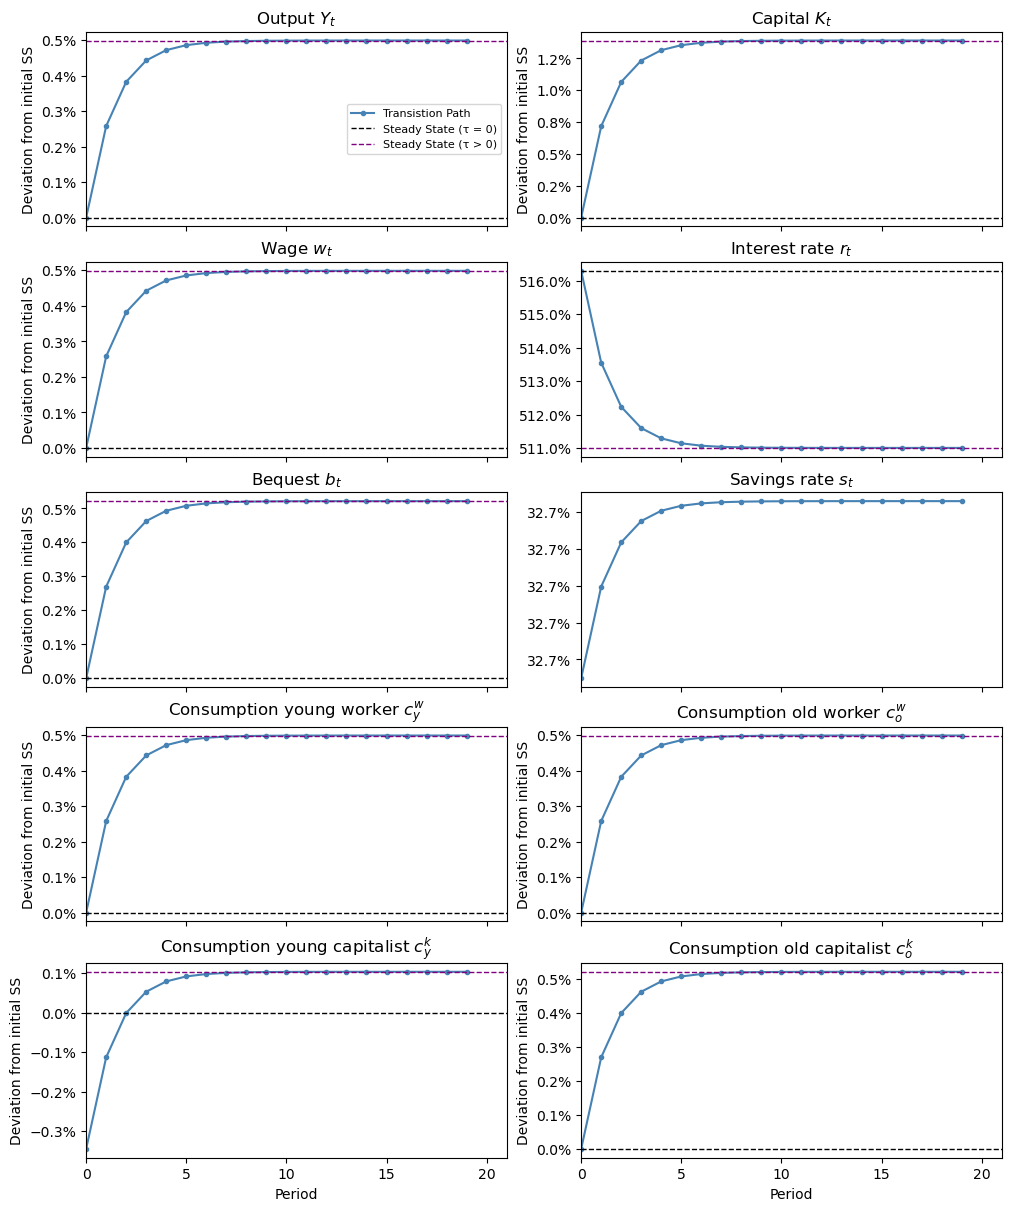

In [87]:
par_base = Parameters(tau_a=0.0)
eq_base = compute_steady_state(par_base)

sim_unc = simulate_olg(K0=eq_base.K, T=20, par=par_unc, uncertain=True)
plot_simulation(eq_base, sim_unc, eq_new=eq_unc)

### 6.5.

**Compare Steady State in Part 6 with Part 2 and Part 5** 

In [88]:
par_taxed = Parameters(tau_a=tau_star)
eq_taxed  = compute_steady_state(par_taxed)

label_w = 15
col_w   = 12

# Print comparison table
print(f"  {"":<{label_w}} {"Part 2":^{col_w}} {"Part 5":^{col_w}} {"Part 6":^{col_w}}")
print(f"  {"":<{label_w}} {"No Tax":^{col_w}} {"Optimal Tax":^{col_w}} {"Uncertain Tax":^{col_w}}")
print(f"  {"-" * (label_w + 3 * col_w + 5)}")

for label, v_base, v_tax, v_unc in [
    ("Capital K", eq_base.K, eq_taxed.K, eq_unc.K),
    ("Output Y", eq_base.Y, eq_taxed.Y, eq_unc.Y),
    ("Interest rate r", eq_base.r, eq_taxed.r, eq_unc.r),
    ("Wage w", eq_base.w, eq_taxed.w, eq_unc.w),
    ("Savings a", eq_base.a, eq_taxed.a, eq_unc.a),
    ("Bequest b", eq_base.b, eq_taxed.b, eq_unc.b),
]:
    print(f"  {label:<{label_w}} {v_base:>{col_w}.{round_digits}f} {v_tax:>{col_w}.{round_digits}f} {v_unc:>{col_w}.{round_digits}f}")

                     Part 2       Part 5       Part 6   
                     No Tax    Optimal Tax  Uncertain Tax
  --------------------------------------------------------
  Capital K             0.0049       0.0046       0.0050
  Output Y              0.0821       0.0804       0.0825
  Interest rate r       5.1629       5.3964       5.1101
  Wage w                0.1314       0.1286       0.1321
  Savings a             0.0492       0.0464       0.0499
  Bequest b             0.1517       0.1423       0.1525


**Interpretation of the three Steady States**

*The three steady states show how different tax regimes affect capital accumulation and economic outcomes.* 

*In the no-tax steady state (Part 2), saving incentives are undistorted and capital equals 0.0049, with wages of 0.1314 and savings of 0.0492. Without taxes, capitalists face no distortions and freely optimise their saving decisions, resulting in the highest capital accumulation among the scenarios. However, there is no redistribution, so workers receive no transfers and inequality between workers and capitalists remains high.* 

*Under the optimal tax steady state (Part 5), a permanent wealth tax of 4.06% reduces capital to 0.0046 and wages to 0.1286. The tax lowers the after-tax return on saving, reducing incentives to accumulate wealth. As a result, savings and bequests fall to 0.0464 and 0.1423. Despite these efficiency costs, redistribution benefits the worker majority and produces the highest social welfare.* 

*With the uncertain tax steady state (Part 6), no tax is imposed, but the possibility of future taxation creates a precautionary savings motive. Capital rises slightly to 0.0050 and wages to 0.1321. This increase is driven by expectations. The capitalists save more today to hedge against future taxes. However, because no tax is collected, workers receive no transfers and do not benefit from redistribution.*